### IMPORT LIBRARY

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
import matplotlib.font_manager as fm
import os

**Graph setting**

In [46]:
%matplotlib inline
sns.set(style="whitegrid")
warnings.filterwarnings("ignore")
candidates = ['TH Sarabun New', 'Noto Sans Thai', 'Tahoma', 'Segoe UI', 'Tahoma', 'Arial Unicode MS']
available = {f.name for f in fm.fontManager.ttflist}
found = [c for c in candidates if c in available]
if found:
    font_choice = found[0]
    import matplotlib as mpl
    mpl.rc('font', family=font_choice)
    mpl.rcParams['axes.unicode_minus'] = False
else:
    print('No recommended Thai fonts found in Matplotlib manager — consider installing Noto Sans Thai or TH Sarabun New')
plt.rcParams.update({'font.size': 12})

### IMPORT RAW DATA

In [47]:
csv_path = "../../data/raw/bangkok_traffy.csv"
df = pd.read_csv(csv_path, parse_dates=["timestamp", "last_activity"], low_memory=False)
print("Loaded df shape:", df.shape)
df.head(5)

Loaded df shape: (787026, 16)


,ticket_id,type,organization,comment,photo,photo_after,coords,address,subdistrict,district,province,timestamp,state,star,count_reopen,last_activity
0,2021-FYJTFP,{ความสะอาด},เขตบางซื่อ,ขยะเยอะ,https://storage.googleapis.com/traffy_public_b...,NaN,"100.53084,13.81865",12/14 ถนน กรุงเทพ- นนทบุรี แขวง บางซื่อ เขตบาง...,NaN,NaN,กรุงเทพมหานคร,2021-09-03 12:51:09.453003+00,เสร็จสิ้น,NaN,0,2022-06-04 15:34:14.609206+00
1,2021-CGPMUN,"{น้ำท่วม,ร้องเรียน}","เขตประเวศ,ฝ่ายโยธา เขตประเวศ",น้ำท่วมเวลาฝนตกและทะลุเข้าบ้านเดือดร้อนมากทุกๆ...,https://storage.googleapis.com/traffy_public_b...,https://storage.googleapis.com/traffy_public_b...,"100.66709,13.67891",189 เฉลิมพระเกียรติ ร.9 แขวง หนองบอน เขต ประเว...,หนองบอน,ประเวศ,กรุงเทพมหานคร,2021-09-19 14:56:08.924992+00,เสร็จสิ้น,4.0,0,2022-06-21 08:21:09.532782+00
2,2021-7XATFA,{สะพาน},เขตสาทร,สะพานลอยปรับปรุงไม่เสร็จตามกำหนด\nปากซอย สาทร12,https://storage.googleapis.com/traffy_public_b...,NaN,"100.52649,13.72060",191/1 ถนน สาทรเหนือ แขวง สีลม เขตบางรัก กรุงเท...,ยานนาวา,สาทร,กรุงเทพมหานคร,2021-09-26 05:03:52.594898+00,เสร็จสิ้น,NaN,0,2022-06-06 01:17:12.272904+00
3,2021-9U2NJT,{น้ำท่วม},"เขตบางซื่อ,ฝ่ายโยธา เขตบางซื่อ",น้ำท่วม,https://storage.googleapis.com/traffy_public_b...,https://storage.googleapis.com/traffy_public_b...,"100.53099,13.81853",12/14 ถนน กรุงเทพ- นนทบุรี แขวง บางซื่อ เขตบาง...,NaN,NaN,กรุงเทพมหานคร,2021-10-14 10:45:27.713884+00,เสร็จสิ้น,NaN,0,2022-09-08 08:35:43.784519+00
4,2021-DVEWYM,"{น้ำท่วม,ถนน}","เขตลาดพร้าว,ฝ่ายโยธา เขตลาดพร้าว",ซอยลาดพร้าววังหิน 75 ถนนลาดพร้าววังหิน แขวงลาด...,https://storage.googleapis.com/traffy_public_b...,NaN,"100.59165,13.82280",702 ถ. ลาดพร้าววังหิน แขวงลาดพร้าว เขตลาดพร้าว...,ลาดพร้าว,ลาดพร้าว,กรุงเทพมหานคร,2021-12-09 12:29:08.408763+00,เสร็จสิ้น,5.0,0,2022-08-12 07:18:44.884945+00


### Step 1 Visualizing Data

### 1.1 Missing value visualization

In [48]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787026 entries, 0 to 787025
Data columns (total 16 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   ticket_id      778254 non-null  object 
 1   type           786929 non-null  object 
 2   organization   786455 non-null  object 
 3   comment        778254 non-null  object 
 4   photo          786911 non-null  object 
 5   photo_after    641309 non-null  object 
 6   coords         787026 non-null  object 
 7   address        778254 non-null  object 
 8   subdistrict    786460 non-null  object 
 9   district       786465 non-null  object 
 10  province       786831 non-null  object 
 11  timestamp      787026 non-null  object 
 12  state          787026 non-null  object 
 13  star           274097 non-null  float64
 14  count_reopen   787026 non-null  int64  
 15  last_activity  787026 non-null  object 
dtypes: float64(1), int64(1), object(14)
memory usage: 96.1+ MB
None


In [49]:
print("\nNull counts (%) (top columns):\n", (df.isnull().mean().sort_values(ascending=False))*100)


Null counts (%) (top columns):
 star             65.173069
photo_after      18.514890
ticket_id         1.114576
comment           1.114576
address           1.114576
organization      0.072552
subdistrict       0.071916
district          0.071281
province          0.024777
photo             0.014612
type              0.012325
coords            0.000000
timestamp         0.000000
state             0.000000
count_reopen      0.000000
last_activity     0.000000
dtype: float64


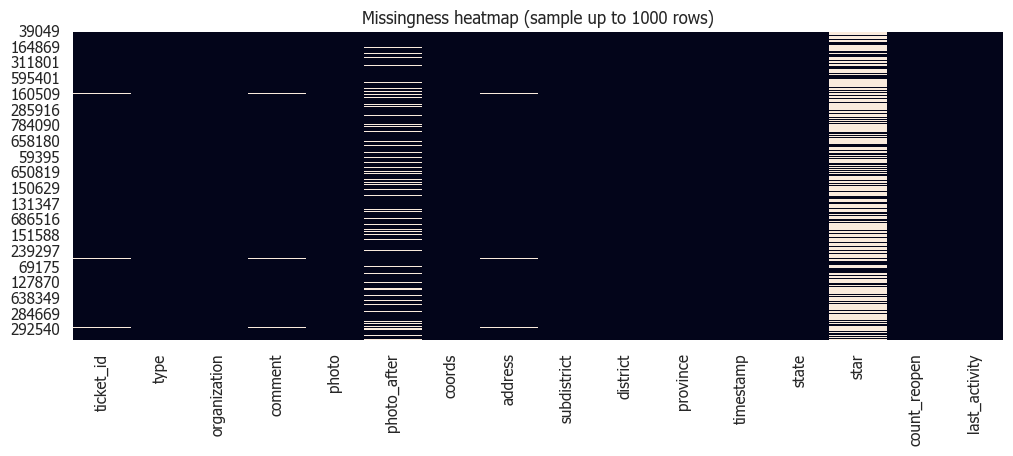

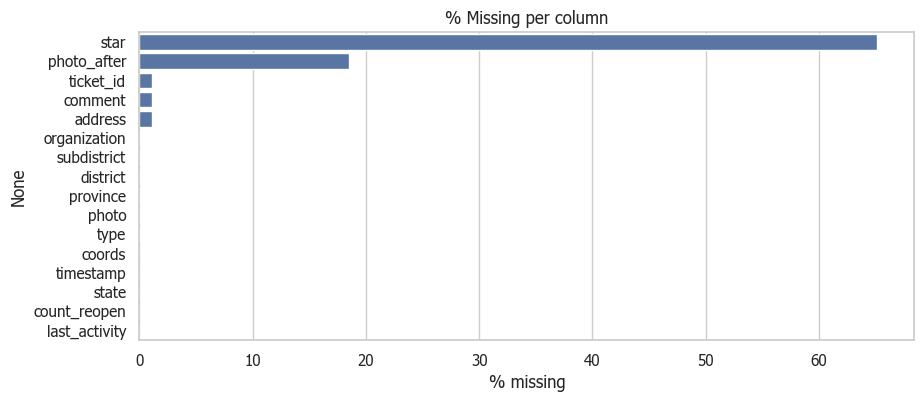

In [50]:
sample = df.sample(min(len(df), 1000), random_state=2)
plt.figure(figsize=(12,4))
sns.heatmap(sample.isnull(), cbar=False)
plt.title('Missingness heatmap (sample up to 1000 rows)')
plt.show()

plt.figure(figsize=(10,4))
null_perc = (df.isnull().mean()*100).sort_values(ascending=False)
sns.barplot(x=null_perc.values, y=null_perc.index)
plt.xlabel('% missing')
plt.title('% Missing per column')
plt.show()


### 1.2 Data Basic Stat

**column format managing**

In [51]:
df['type_clean'] = df['type'].astype(str).str.replace('[{}]', '', regex=True).str.strip()
df['has_photo'] = df['photo'].notnull() | df['photo_after'].notnull()
df['comment_len'] = df['comment'].fillna('').str.len()

coords = df['coords'].astype(str).str.split(',', expand=True)
if coords.shape[1] >= 2:
    df['lon'] = pd.to_numeric(coords[0].str.strip(), errors='coerce')
    df['lat'] = pd.to_numeric(coords[1].str.strip(), errors='coerce')

**Top 20 Issue Types**

Bar chart showing the top 20 cleaned issue types (helps prioritize common issues).

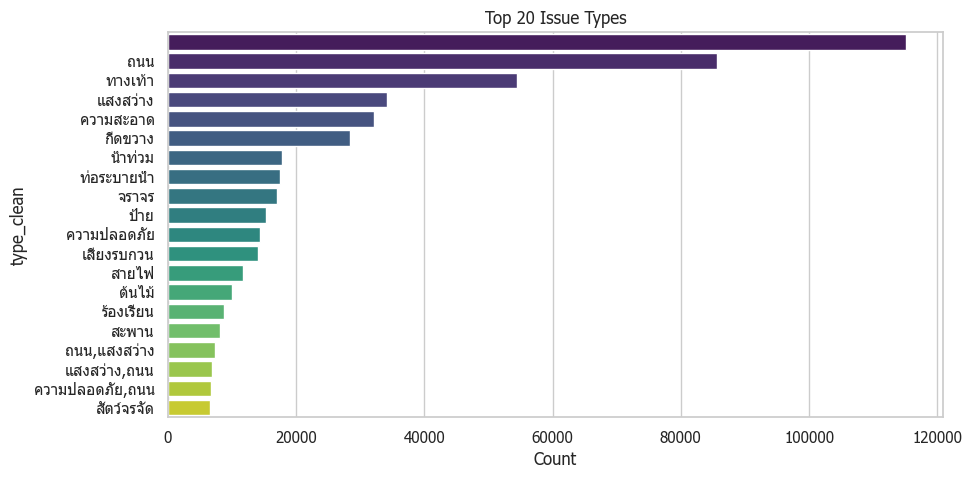

In [52]:
plt.figure(figsize=(10,5))
if 'type_clean' in df.columns:
    sns.barplot(y=df['type_clean'].value_counts().nlargest(20).index, x=df['type_clean'].value_counts().nlargest(20).values, palette='viridis')
    plt.title('Top 20 Issue Types')
    plt.xlabel('Count')
    plt.show()
else:
    print('No `type_clean` column available')


**Top 20 Districts**

Bar chart for the top 20 districts by number of tickets.

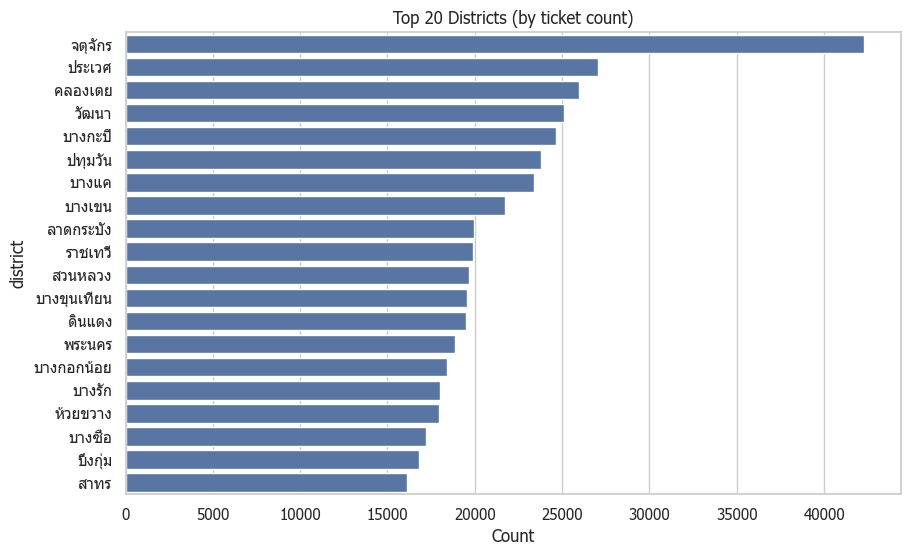

In [53]:
plt.figure(figsize=(10,6))
if 'district' in df.columns:
    sns.barplot(y=df['district'].value_counts().nlargest(20).index, x=df['district'].value_counts().nlargest(20).values)
    plt.title('Top 20 Districts (by ticket count)')
    plt.xlabel('Count')
    plt.show()
else:
    print('No `district` column available')


**Tickets by State**

Count of tickets grouped by `state` field.

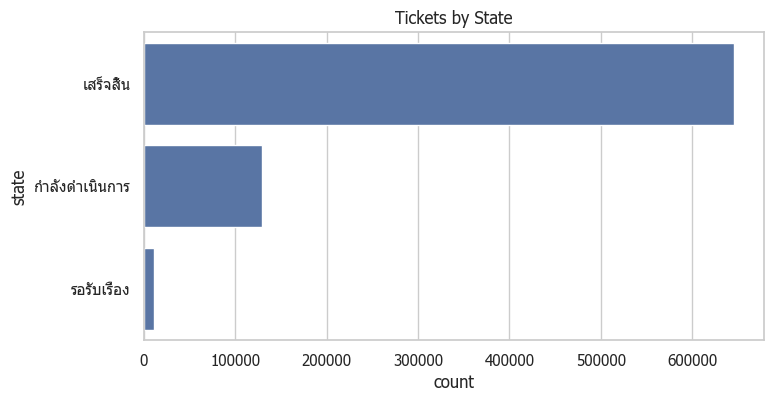

In [54]:
plt.figure(figsize=(8,4))
ax = None
if 'state' in df.columns:
    ax = sns.countplot(y='state', data=df, order=df['state'].value_counts().index)
    plt.title('Tickets by State')
    plt.show()
else:
    print('`state` column not available')


**Star Distribution**

Histogram of `star` ratings (only non-null values). Shows distribution and percent missing.

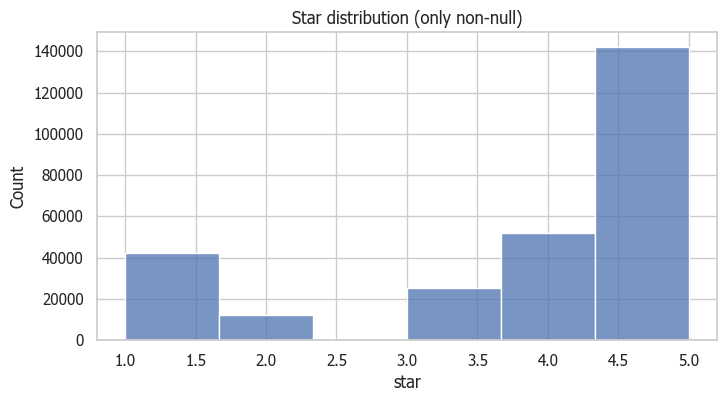

Percent star missing:  65.17306925057113


In [55]:
plt.figure(figsize=(8,4))
if 'star' in df.columns:
    sns.histplot(df['star'].dropna(), bins=6, kde=False)
    plt.title('Star distribution (only non-null)')
    plt.show()
    print('Percent star missing: ', df['star'].isnull().mean()*100)
else:
    print('No `star` column present.')


**Map of Ticket Locations**

Interactive map (Plotly) showing ticket locations. Uses a sample up to 2000 points for performance.

In [56]:
if 'lat' in df.columns and 'lon' in df.columns:
    df_map = df.dropna(subset=['lat','lon']).copy()
    if len(df_map) > 2000:
        df_map = df_map.sample(2000, random_state=42)
    fig = px.scatter_mapbox(df_map, lat='lat', lon='lon', color='state', hover_name='ticket_id', hover_data=['type_clean','district'], zoom=10, height=600)
    fig.update_layout(mapbox_style='open-street-map')
    fig.update_layout(title='Ticket Locations (sample up to 2000)')
    fig.show()
else:
    print('No valid lat/lon to plot (coords missing/invalid)')


**Comment Length Distribution**

Distribution of comment lengths (characters) to inspect how verbose reports are.

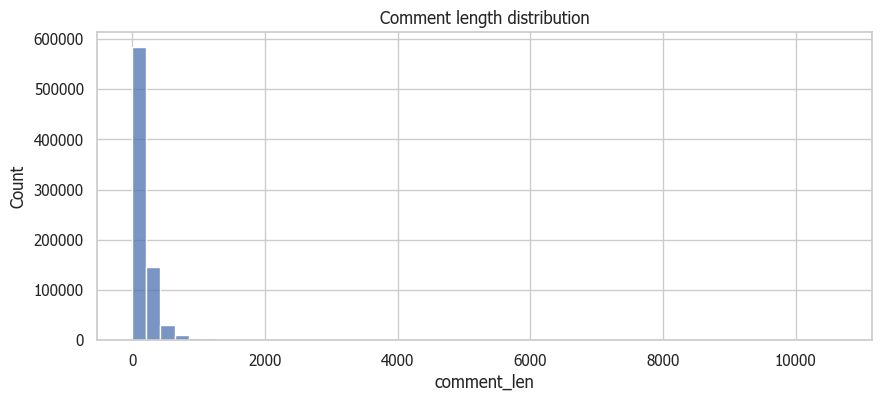

In [57]:
plt.figure(figsize=(10,4))
if 'comment_len' in df.columns:
    sns.histplot(df['comment_len'].dropna(), bins=50)
    plt.title('Comment length distribution')
    plt.show()
else:
    print('No comment length data available')


**Count of Reopen**

Bar chart of the `count_reopen` column showing distribution of how many times tickets were reopened.

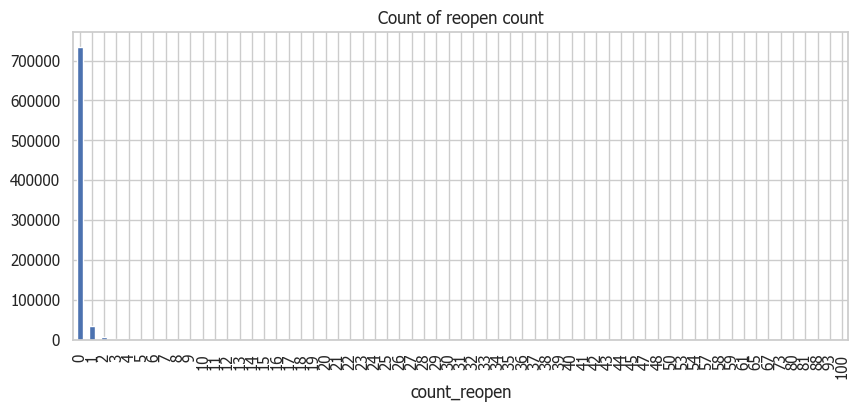

In [58]:
plt.figure(figsize=(10,4))
val = df['count_reopen'].value_counts().sort_index()
if not val.empty:
    val.plot(kind='bar')
    plt.title('Count of reopen count')
    plt.xlabel('count_reopen')
    plt.show()
else:
    print('No reopen count data to plot')


**Top 20 Provinces**

Bar chart showing the top 20 provinces by ticket count.

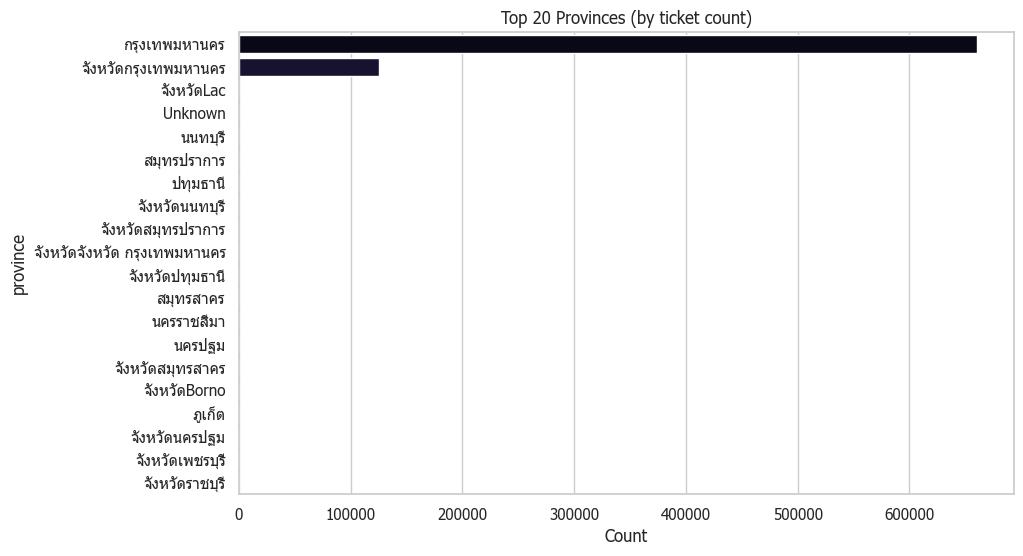

In [59]:
prov_counts = df["province"].fillna("Unknown").value_counts()
top_prov = prov_counts.nlargest(20)
if not top_prov.empty:
    plt.figure(figsize=(10,6))
    sns.barplot(y=top_prov.index, x=top_prov.values, palette="magma")
    plt.title("Top 20 Provinces (by ticket count)")
    plt.xlabel("Count")
    plt.show()
else:
    print("No province data available to plot.")


### 2. Cleansing Data

**Droping star column due to more than 50% null data (65%)**

In [60]:
if 'star' in df.columns:
    star_pct_missing = df['star'].isnull().mean() * 100
    print(f"star missing: {star_pct_missing:.2f}%")
    if star_pct_missing > 50:
        print("Dropping 'star' column because >50% missing")
        df.drop(columns=['star'], inplace=True)
    else:
        print("Keeping 'star' column; converting to numeric and coercing invalid values to NaN")
        df['star'] = pd.to_numeric(df['star'], errors='coerce')
else:
    print("'star' column not present")


star missing: 65.17%
Dropping 'star' column because >50% missing


**Choose only กรุงเทพมหานคร and drop other province**

In [61]:
df['province'] = df['province'].astype(str).str.strip()
df.loc[df['province'].str.contains('กรุงเทพ', na=False), 'province'] = 'กรุงเทพมหานคร'
df_bkk = df[df['province'] == 'กรุงเทพมหานคร'].copy()
df_bkk['province'].value_counts()

province
กรุงเทพมหานคร    785656
Name: count, dtype: int64

**Drop row with empty type due to model requirement**

In [62]:
df_bkk.dropna(subset=['type','district','subdistrict','organization'], how='any', inplace=True)

In [63]:
df_bkk.isnull().sum()

ticket_id          8700
type                  0
organization          0
comment            8700
photo                98
photo_after      144822
coords                0
address            8700
subdistrict           0
district              0
province              0
timestamp             0
state                 0
count_reopen          0
last_activity         0
type_clean            0
has_photo             0
comment_len           0
lon                   0
lat                   0
dtype: int64

In [64]:
cols_to_fill = [c for c in df_bkk.columns]

print('Columns to fill (except required):', cols_to_fill)

num_cols = df_bkk[cols_to_fill].select_dtypes(include=['number']).columns.tolist()
if num_cols:
    df_bkk[num_cols] = df_bkk[num_cols].fillna(0)

bool_cols = df_bkk[cols_to_fill].select_dtypes(include=['bool']).columns.tolist()
if bool_cols:
    df_bkk[bool_cols] = df_bkk[bool_cols].fillna(False)

dt_cols = [c for c in cols_to_fill if pd.api.types.is_datetime64_any_dtype(df_bkk[c])]
for c in dt_cols:
    df_bkk[c] = df_bkk[c].fillna(pd.Timestamp('1970-01-01'))

obj_cols = [c for c in cols_to_fill if c not in num_cols + bool_cols + dt_cols]
if obj_cols:
    df_bkk[obj_cols] = df_bkk[obj_cols].fillna('')


Columns to fill (except required): ['ticket_id', 'type', 'organization', 'comment', 'photo', 'photo_after', 'coords', 'address', 'subdistrict', 'district', 'province', 'timestamp', 'state', 'count_reopen', 'last_activity', 'type_clean', 'has_photo', 'comment_len', 'lon', 'lat']


In [65]:
df_bkk.isnull().sum()

ticket_id        0
type             0
organization     0
comment          0
photo            0
photo_after      0
coords           0
address          0
subdistrict      0
district         0
province         0
timestamp        0
state            0
count_reopen     0
last_activity    0
type_clean       0
has_photo        0
comment_len      0
lon              0
lat              0
dtype: int64

In [67]:
import os
out_dir = '../../data/processed'
os.makedirs(out_dir, exist_ok=True)

full_out_path = os.path.join(out_dir, 'bangkok_traffy_full_cleaned.csv')
df_bkk.to_csv(full_out_path, index=False)
print(f'Saved full cleaned dataset ({len(df_bkk)} rows) to {full_out_path}')

sample_n = 300000

sample_df = df_bkk.sample(n=sample_n, random_state=42)
print(f'Sampled {sample_n} rows (random_state=42)')


sample_out_path = os.path.join(out_dir, f'bangkok_traffy_sample_{len(sample_df)}.csv')
sample_df.to_csv(sample_out_path, index=False)
print(f'Saved sample ({len(sample_df)} rows) to {sample_out_path}')


Saved full cleaned dataset (785392 rows) to ../../data/processed\bangkok_traffy_full_cleaned.csv
Sampled 300000 rows (random_state=42)
Sampled 300000 rows (random_state=42)
Saved sample (300000 rows) to ../../data/processed\bangkok_traffy_sample_300000.csv
Saved sample (300000 rows) to ../../data/processed\bangkok_traffy_sample_300000.csv
